# Prediction

Dengue federated analysis workshop.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ISARICResearch/Dissemination/blob/main/workshops/federated%20analytics/FederatedAnalysis_Project/notebooks/05_prediction.ipynb)

## Introduction

Predictive modelling uses data from past cases to estimate the outcome of new cases whose outcome isn't known yet. Unlike the explanatory approach used in the odds ratio analysis (`03_odds_ratios.ipynb`), where the goal is to understand how each variable is associated with the outcome, the goal here is to predict the outcome as accurately as possible, which is why the model is evaluated on data it didn't see during training. During an outbreak, it can help identify early the patients at higher risk of a severe outcome, supporting clinical decisions and the allocation of resources.

This notebook walks through the full process of training and evaluating a logistic regression model to predict whether a patient survives (alive or dead), using the workshop's dummy dengue dataset.

## Objective

Compare the predictive performance of the model obtained with the centralized and federated approaches, to evaluate whether they match and identify where they diverge. The workshop uses a dummy dengue dataset from 5 health institutions.

## Table of Contents

```
1. Setup
    1.1. Environment detection
    1.2. Install dependencies
    1.3. Get project files
    1.4. Imports
    1.5. Load data
2. Data Preparation
    2.1. Drop unused columns
    2.2. Drop rows with missing key values
    2.3. Impute missing values
    2.4. Encode categorical values to numeric
    2.5. Correlation between predictors
3. Train and Test Data
    3.1. Outcome distribution
    3.2. Train/test split
4. Centralized Approach
    4.1. Separate outcome and predictors
    4.2. Model pipeline
    4.3. Hyperparameter grid
    4.4. Grid search and best hyperparameters
    4.5. Prediction metrics
    4.6. Confusion matrix
    4.7. Model coefficients
5. Federated Approach
    5.1. Split the data by institution
    5.2. Federated scaler
    5.3. Site models
    5.4. Iterative training
    5.5. Federated evaluation
6. Comparison
    6.1. Model coefficients
    6.2. Prediction metrics
    6.3. Confusion matrices
    6.4. Interpreting the results
7. Conclusions
```

## 1. Setup

Prepare everything the notebook needs before starting the analysis.

### 1.1. Environment detection

Check whether this notebook is running on Google Colab or on a local computer.

In [1]:
import sys

# True on Google Colab, False on a local computer
IN_COLAB = "google.colab" in sys.modules

### 1.2. Install dependencies

Install any extra packages this notebook needs. This step only runs on Google Colab. On a local computer, the packages are already installed.

This notebook uses scikit-learn 1.6.1, so this exact version is installed to guarantee the same results as when the notebook was written.

In [2]:
if IN_COLAB:
    # Same scikit-learn version this notebook was written for; nothing is installed if Colab already has it
    %pip install -q scikit-learn==1.6.1

### 1.3. Get project files

Get the project's data and code. On Google Colab, only the project's folder is downloaded first from the repository where it's published; on a local computer, they're already available next to this notebook.

In [3]:
from pathlib import Path

# Repository the project is downloaded from on Google Colab, and the project's folder inside it
REPO_URL, PROJECT_PATH = "https://github.com/ISARICResearch/Dissemination.git", "workshops/federated analytics/FederatedAnalysis_Project"
REPO_NAME = Path(REPO_URL).stem

if IN_COLAB:
    # Download only this project's folder, not the whole repository
    project_dir = Path(REPO_NAME) / PROJECT_PATH
    if not project_dir.exists():
        !git clone --depth 1 --filter=blob:none --sparse {REPO_URL}
        !git -C {REPO_NAME} sparse-checkout set "{PROJECT_PATH}"
else:
    # This notebook already lives inside the project
    project_dir = Path("..")

# Make the project's own code importable (e.g. `analysis_lib`)
sys.path.insert(0, str(project_dir))

data_dir = project_dir / "data"
data_file = data_dir / "dummy_data.parquet"
dictionary_file = data_dir / "dummy_data_dictionary.json"

### 1.4. Imports

Load the Python libraries used in this notebook.

In [4]:
# Standard library
import json
import warnings

# Third-party
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Project
from analysis_lib.eda import plot_distribution_by_site
from analysis_lib.prediction import (
    combine_site_evaluations,
    evaluate_model,
    model_coefficients,
    plot_confusion_matrices,
    plot_confusion_matrix,
    plot_correlation_heatmap,
    scaler_from_statistics,
    site_evaluation,
    strongest_correlations,
)
from analysis_lib.preprocessing import drop_columns_by_category, encode_yes_no, fillna_by_category

### 1.5. Load data

Read the example data.

In [5]:
# Load the full example dataset
df = pd.read_parquet(data_file)

# Load the data dictionary that describes each column
with open(dictionary_file, encoding="utf-8") as f:
    data_dictionary = json.load(f)

## 2. Data Preparation

Prepare the dataset for the prediction model: keep only the relevant columns, remove rows that can't be used, fill in missing values, and encode every column as a number so it can be used in a logistic regression.

### 2.1. Drop unused columns

Remove the columns not needed for the prediction model: identification (`record_id`) and dates, plus `final_classification` and `hospitalized` (kept out of the predictor set).

Two more groups of columns are removed:

- Exam columns (`tissue_sample_taken` and the 7 organ-specific tissue samples: `liver_sample`, `spleen_sample`, `lung_sample`, `brain_sample`, `myocardium_sample`, `bone_marrow_sample`, `kidney_sample`): these samples are almost always taken after death (only 2 of the 57 patients with `tissue_sample_taken = "Yes"` are alive, see `03_odds_ratios.ipynb`, section 2.5). They wouldn't be available when predicting the outcome of a new patient, and using them would let the model learn the outcome from information recorded after it happened. This problem is known as **data leakage**.
- `fever`: every patient had it, so it carries no information about the outcome.

`petechiae`, which was also removed in `03_odds_ratios.ipynb` because none of the 28 patients with it died, is kept in this case: the model used here limits the size of its coefficients (regularization, see section 4), which keeps the contribution of a predictor like this one bounded and reduces that of predictors that add little to the prediction.

The model therefore predicts the `outcome` from the symptoms, `age` and `sex`.

In [6]:
# Drop identification and date columns, plus exam columns (tissue samples almost always taken after death: data leakage)
df = drop_columns_by_category(df, data_dictionary, categories_to_drop=["Identification", "Date", "Exam"])

# Drop columns not used as predictors, and fever (every patient had it)
df = df.drop(columns=["final_classification", "hospitalized", "fever"])

### 2.2. Drop rows with missing key values

Remove records that can't be used in the analysis: with no data at all, with no known outcome, or with no known institution.

This dataset doesn't have any, but the check is included as a standard data-cleaning step.

In [7]:
df = df.dropna(how="all")
df = df.dropna(subset=["outcome", "institution"])

### 2.3. Impute missing values

Fill in the remaining missing values before modelling, since logistic regression can't handle them.

- Symptom columns: a missing value means the symptom wasn't recorded, so it's filled as `"No"`.
- `sex`: a missing value is filled as `"Unknown"` (this dataset has none, this step is included for completeness).

In [8]:
# A missing symptom means it wasn't observed, treated the same as "No"
df = fillna_by_category(df, data_dictionary, categories=["Symptom"], fill_value="No")

# No missing sex values exist in this dataset; included for completeness
df["sex"] = df["sex"].fillna("Unknown")

### 2.4. Encode categorical values to numeric

Convert every categorical column into numbers, as required by the logistic regression model.

- Symptom columns: `"Yes"`/`"No"` → `1`/`0`.
- `sex`: `"Female"`/`"Male"` → `0`/`1`.
- `outcome`: `"Alive"`/`"Dead"` → `0`/`1`, so the model estimates the probability of death.

In [9]:
# Encode every symptom column from "Yes"/"No" to 1/0
df = encode_yes_no(df, data_dictionary, categories=["Symptom"])

# Encode sex and the outcome; "Dead" is coded as 1 so the model estimates the probability of death
df["sex"] = df["sex"].map({"Female": 0, "Male": 1}).astype(int)
df["outcome"] = df["outcome"].map({"Alive": 0, "Dead": 1}).astype(int)

### 2.5. Correlation between predictors

Check whether any pair of predictors is strongly correlated, that is, whether both tend to take the same values in the same patients. In that case, the two predictors carry mostly the same information: the second one adds little that the model doesn't already get from the first, and the coefficients of both become unreliable. When a pair exceeds the recommended threshold of 0.7, one of the two is usually removed.

The correlation is shown in absolute value, from 0 (no correlation) to 1 (perfect correlation): whether it's positive or negative, a strong correlation means the same redundancy. The outcome isn't part of this check: predictors are only compared with each other.

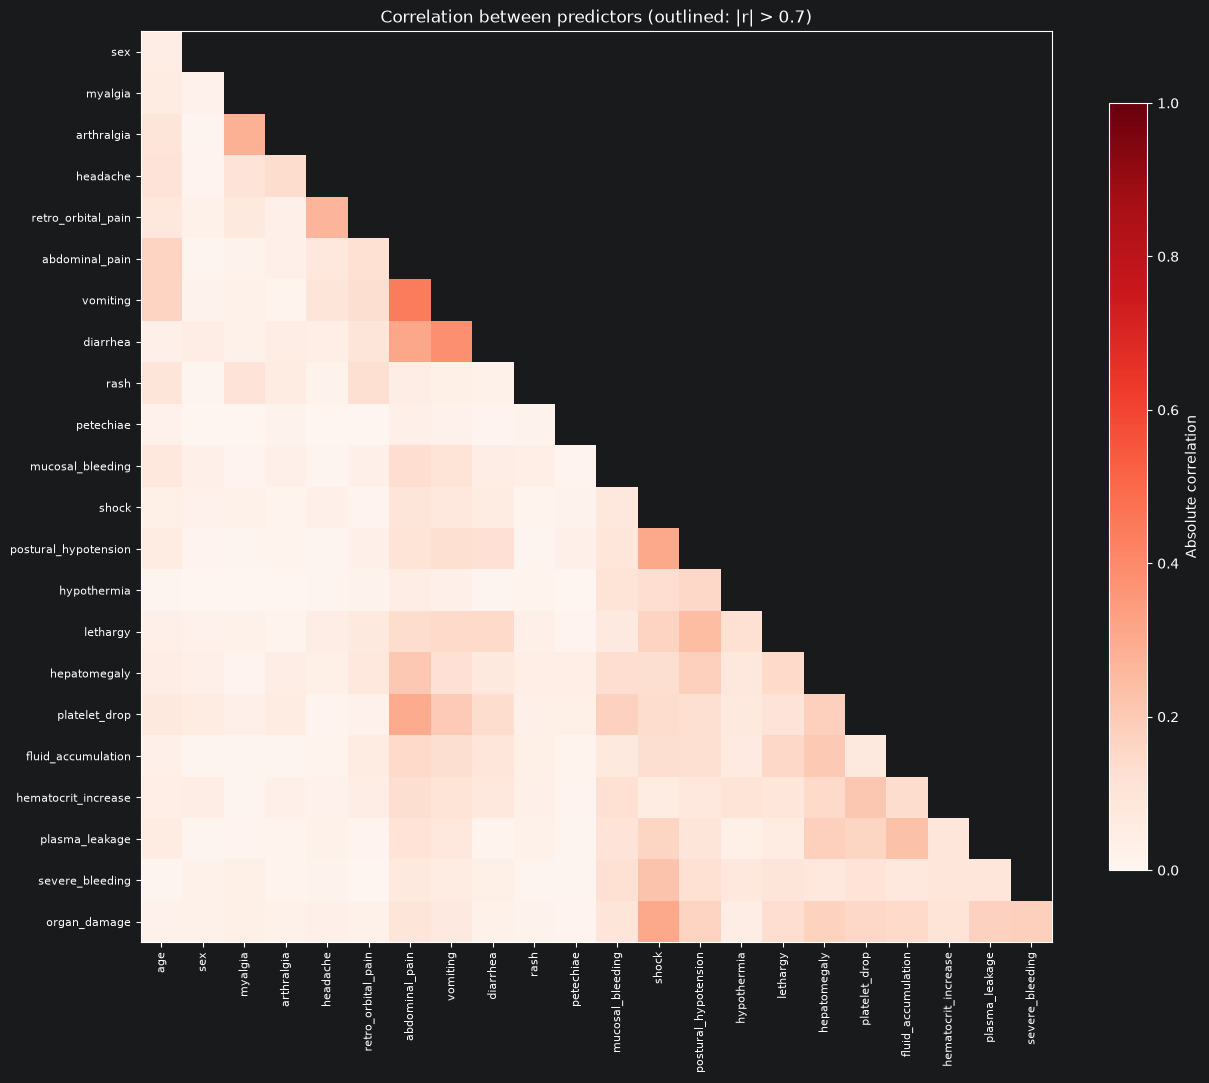

Absolute correlation
Predictor 1          Predictor 2                         
vomiting             abdominal_pain                 0.445
diarrhea             vomiting                       0.383
                     abdominal_pain                 0.311
organ_damage         shock                          0.308
postural_hypotension shock                          0.306

In [10]:
# Every column except the outcome and institution
predictors = [column for column in df.columns if column not in ("outcome", "institution")]

plot_correlation_heatmap(df, predictors=predictors, threshold=0.7)

# Show the pairs with the strongest correlation
display(strongest_correlations(df, predictors=predictors, n=5))

No pair of predictors comes close to the 0.7 threshold.

The strongest correlation is 0.45, between `abdominal_pain` and `vomiting`, followed by `vomiting` and `diarrhea` (0.38). Symptoms that often appear together are moderately correlated, but each still carries its own information, so all 23 predictors are kept.

The regularization to be used by the model (section 4) also handles moderate correlations like these.

## 3. Train and Test Data

Split the dataset into a training set, used to fit the model, and a test set, used only to evaluate it on patients it didn't see during training.

### 3.1. Outcome distribution

Plot the percentage of survivors and deaths, overall and per institution, before splitting the data.

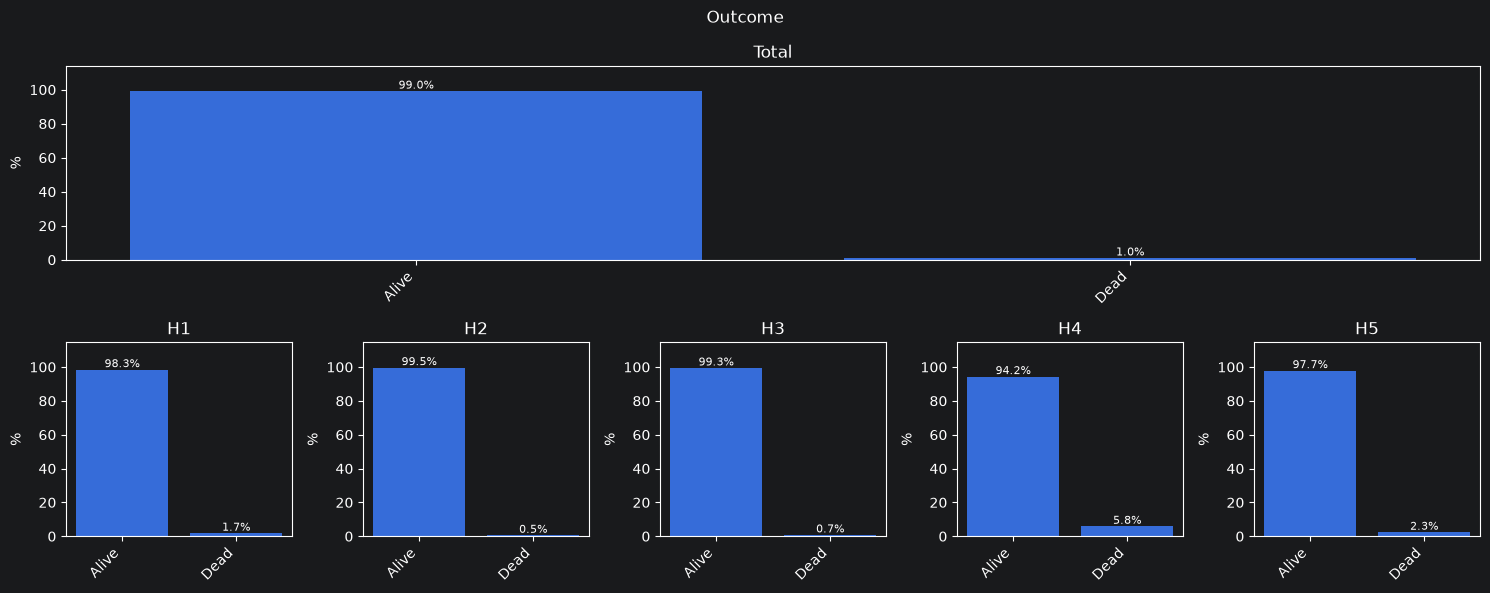

In [11]:
# A copy with the outcome's original labels, only for plotting
plot_df = df.assign(outcome=df["outcome"].map({0: "Alive", 1: "Dead"}))

plot_distribution_by_site(plot_df, column="outcome", normalize=True, title="Outcome", show_values=True)

The plots show a strong imbalance: only 1.0% of patients died, and mortality varies between institutions, from 0.5% (H2) to 5.8% (H4).

### 3.2. Train/test split

With so few deaths, a purely random split could leave the training and test sets, or an institution's share of them, with noticeably different proportions of deaths. For this reason, the split is stratified by institution and outcome, so that both sets keep similar outcome distributions, overall and within each institution.

70% of the records are used for training and 30% for testing. The same split is used by both the centralized and federated approaches, so both are evaluated on exactly the same patients, and each institution keeps its own local training and test data. A fixed random seed (`random_state`) makes the split reproducible.

In [12]:
# Each record's stratum: its institution combined with its outcome (e.g. "H1_0", "H1_1")
strata = df["institution"] + "_" + df["outcome"].astype(str)

train_df, test_df = train_test_split(df, test_size=0.3, stratify=strata, random_state=42)

## 4. Centralized Approach

Train and evaluate the model with all institutions' data together, as if every institution shared its records directly.

### 4.1. Separate outcome and predictors

Identify the outcome column and the columns used as predictors, in both the training and test sets. `institution` is excluded: it isn't a predictor here, it's kept for splitting the data by site in the federated approach.

In [13]:
outcome = "outcome"

# Every column except the outcome and institution
predictors = [column for column in df.columns if column not in (outcome, "institution")]

X_train, y_train = train_df[predictors], train_df[outcome]
X_test, y_test = test_df[predictors], test_df[outcome]

### 4.2. Model pipeline

Define the model as a pipeline of two steps: scaling the predictors, then fitting the logistic regression.

**Scaling.** The regularization described below penalizes the size of the coefficients, and a coefficient's size depends on its predictor's units (e.g. `age` in years against 0/1 symptoms). Every predictor is therefore scaled to mean 0 and standard deviation 1 (`StandardScaler`), so all of them are penalized equally. Scaling every predictor to the range 0 to 1 (`MinMaxScaler`) wouldn't achieve this: a symptom only a few patients have varies less than a common one, so it would need a larger coefficient for the same effect and would be penalized more. The scaling is learnt from the training data only, and then applied to both sets.

**Model configuration.** The following choices come from what the data has shown so far:

- **Class imbalance.** Only 1% of patients died (section 3.1), so `class_weight="balanced"` is used: each death weighs more during training, in proportion to how rare deaths are, so the model doesn't learn to simply predict that every patient survives.
- **Regularization.** With few deaths relative to the number of predictors, the model tends to overfit: it learns patterns specific to these patients that don't hold for new ones. Also, predictors like `petechiae` (section 2.1), where none of the patients with it died, would get a coefficient that grows without limit. Regularization limits the size of the coefficients, which addresses both problems.
- **Initial values.** The federated approach (section 5) trains the model iteratively: in each round, every institution continues training from the coefficients the server sends. The solver, the algorithm that fits the model, must therefore accept initial values that are adjusted in each round. The solvers that support this are `lbfgs`, `newton-cg`, `newton-cholesky`, `sag` and `saga`.
- **Convergence.** Of these, `lbfgs`, scikit-learn's default solver, converges without problems with `class_weight="balanced"` and is the one used.

In [14]:
# Scaling and model in one pipeline, so scaling is always learnt from the data the model is fit on
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(solver="lbfgs", class_weight="balanced")),
])

### 4.3. Hyperparameter grid

Define the values of the model's hyperparameters to evaluate. `lbfgs` only supports Ridge (L2) regularization, so the only hyperparameter to search is `C`, the inverse of the regularization strength: smaller values of `C` mean stronger regularization, which limits the coefficients more to prevent overfitting (section 4.2).

The values go from 0.00001 (very strong regularization) to 10 (very weak), each 10 times the previous one.

In [15]:
# Values of C to evaluate, each 10 times the previous: smaller values mean stronger regularization
param_grid = {"model__C": [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10]}

### 4.4. Grid search and best hyperparameters

Train the model with each value of `C` and keep the one that performs best. Each value is evaluated on the training data only, with 5-fold cross-validation (the model is trained on 4 parts of the training set and evaluated on the remaining one, rotating the part used for evaluation). Each fold keeps a similar proportion of deaths.

The following metrics are commonly used to evaluate a classification model:

| Metric | What it measures | Analysis |
|---|---|---|
| Accuracy | Share of all patients correctly classified | Not suitable: survivors are 99% of patients, so they dominate the result. Predicting that every patient survives already gives 99% accuracy without detecting a single death. |
| Recall | Share of deaths the model detects | Not suitable on its own: it ignores false alarms, so predicting that every patient dies gives 100%. |
| Precision | Share of predicted deaths that actually died | Not suitable on its own: it ignores missed deaths, and with so few deaths even a good model gets a low value, since a small share of false alarms among the survivors already outnumbers the deaths. |
| F1 | Balance between recall and precision | Better suited to imbalanced data, since it focuses on deaths. But it depends on the probability threshold used to classify patients, so it evaluates one way of classifying rather than the model as a whole, and it changes with mortality, which varies between institutions (0.5% at H2 to 5.8% at H4). |
| AUC | How well the model ranks patients who died above those who survived, across all thresholds | Suitable for choosing `C`: it doesn't depend on the threshold or on how common deaths are. It doesn't show how many deaths are detected at the chosen threshold, which is why every metric is reported when evaluating the model on the test set. |

In [16]:
# 5-fold cross-validation, each fold with a similar proportion of deaths
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(pipeline, param_grid, scoring="roc_auc", cv=cv)
grid_search.fit(X_train, y_train)

print("Best C:", grid_search.best_params_["model__C"])

Best C: 0.0001


### 4.5. Prediction metrics

Evaluate the model on the test set, made up of patients it didn't see during training. After the search, the model is trained again on the whole training set with the best value of `C`, and that is the model evaluated here.

A patient is classified as dead when the predicted probability of death is above 0.5. The metrics are the ones described in section 4.4.

In [17]:
# Model trained again on the whole training set with the best C
best_model = grid_search.best_estimator_

results_centralized = evaluate_model(best_model, X_test, y_test)
display(results_centralized.round(3).to_frame("Centralized"))

,Centralized
Accuracy,0.970
Recall,0.931
Precision,0.229
F1,0.367
AUC,0.986


- **AUC (0.986):** The model ranks patients by risk very well. Comparing a patient who died with one who survived, the one who died gets the higher probability of death in 98.6% of the pairs.
- **Recall (0.931) and precision (0.229):** with the 0.5 threshold, the model detects 93% of deaths, but only 23% of the patients it predicts as dead actually died. As anticipated in section 4.4, with so few deaths a small share of false alarms among the survivors already outnumbers the deaths. F1 (0.367) is low because of this low precision.
- **Accuracy (0.970):** it looks high, but it's mostly driven by the survivors (section 4.4), so it says little about how well the model detects deaths.

### 4.6. Confusion matrix

Show how many test patients were classified correctly and incorrectly. Each row is the true outcome and each column the predicted one, so the diagonal holds the correct predictions. Each cell shows the number of patients and, in parentheses, their percentage of the patients with that true outcome.

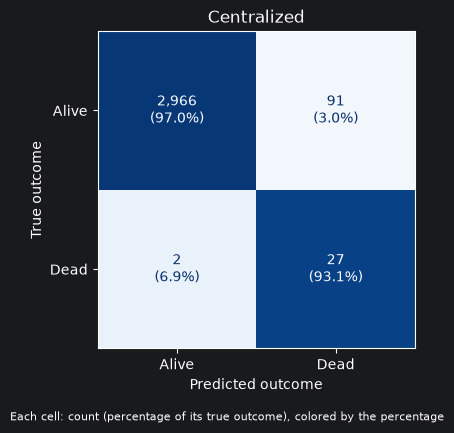

In [18]:
plot_confusion_matrix(best_model, X_test, y_test, title="Centralized")

Of the 29 deaths in the test set, the model detects 27 and misses 2. In exchange, 91 of the 3,057 survivors (3%) are false alarms, more than three times the number of deaths. This is why precision is low (section 4.5): only 27 of the 118 patients predicted as dead actually died.

### 4.7. Model coefficients

Show the coefficient the model learnt for each predictor. Since the predictors were scaled (section 4.2), the coefficients can be compared with each other: a larger absolute value means a larger contribution to the prediction, positive values increase the predicted probability of death and negative values decrease it.

In [19]:
coefficients_centralized = model_coefficients(best_model, predictors)
display(coefficients_centralized.sort_values(ascending=False).round(4).to_frame("Centralized"))

,Centralized
shock,0.2747
organ_damage,0.1825
severe_bleeding,0.1354
postural_hypotension,0.0981
plasma_leakage,0.0665
lethargy,0.0524
platelet_drop,0.0464
abdominal_pain,0.0359
hypothermia,0.0340
age,0.0283


## 5. Federated Approach

Train and evaluate the model without sharing individual records. Each institution works only with its own data, and shares with a central server only the values the server needs to combine the institutions' work.

### 5.1. Split the data by institution

Separate the training and test sets into one subset per institution. Each subset simulates the data a single hospital holds locally: its own training and test records from the split in section 3.2.

From here on, each hospital uses only its own data, which never leaves it. What each hospital shares isn't this data, but summary values and the model's parameters.

In [20]:
sites = sorted(df["institution"].unique())

# Simulate each institution's local data: its own training and test records
site_train = {site: train_df.loc[train_df["institution"] == site] for site in sites}
site_test = {site: test_df.loc[test_df["institution"] == site] for site in sites}

### 5.2. Federated scaler

For data scaling, each institution can't use its own mean and standard deviation, because the same value (e.g. 30 years) would be scaled differently considering the different data distributions. As a result, the same coefficient across the different models would mean something different at each one, and their models couldn't be combined.

The idea is to compute a common scale across all institutions, as in the centralized approach (`StandardScaler`, section 4.2). To do this, it is necessary to calculate the mean and the standard deviation with the federated approach, as in `02_descriptive_analysis.ipynb` (section 5.3). Each institution shares only its number of records ($n_i$), the sum of each predictor ($\sum x$) and the sum of its squares ($\sum x^2$), computed from its own training data. The central server adds them up and computes the global mean and standard deviation:

$$\bar{x} = \frac{\sum x}{n} \qquad sd = \sqrt{\frac{\sum x^2}{n} - \bar{x}^2}$$

With them, the server builds the scaler every institution uses.

In [21]:
# Each institution: summary values of its own training data, the only values it shares
shared_values = {
    site: {
        "n": len(data),
        "sum": data[predictors].sum(),
        "sum_squares": (data[predictors] ** 2).sum(),
    }
    for site, data in site_train.items()
}

# Central server: add up every institution's values
n_total = sum(values["n"] for values in shared_values.values())
sum_total = sum(values["sum"] for values in shared_values.values())
sum_squares_total = sum(values["sum_squares"] for values in shared_values.values())

# Global mean and standard deviation of each predictor
global_mean = sum_total / n_total
global_std = (sum_squares_total / n_total - global_mean ** 2) ** 0.5

# Scaler shared with every institution
federated_scaler = scaler_from_statistics(global_mean, global_std)

### 5.3. Site models

Each institution prepares its own data and model. It separates the outcome and predictors of its training data, as in section 4.1, and scales the predictors with the common scaler from section 5.2.

Each institution's model has the same configuration as the centralized one (section 4.2), with the best value of `C` found in section 4.4. It's reused here so that both approaches use the same hyperparameters and the comparison shows only the effect of training in a federated way. Two settings change, both needed to train in rounds (section 5.4):

- **Starting point (`warm_start=True`).** Each time the model trains, it starts from the coefficients it already has, which will be the ones the server sends, instead of starting from zero.
- **One step per round (`max_iter=1`).** Each institution takes a single training step per round. If it trained until the end, it would reach its own best model regardless of where it started, and combining in rounds would add nothing.

`class_weight="balanced"` is computed by each institution from its own data, so each one balances its own deaths and survivors.

In [22]:
best_C = grid_search.best_params_["model__C"]

site_X_train, site_y_train, site_models = {}, {}, {}
for site, data in site_train.items():
    # Each institution: its own predictors, scaled with the common scaler, and its outcome
    site_X_train[site] = federated_scaler.transform(data[predictors])
    site_y_train[site] = data[outcome]

    # Same configuration as the centralized model, trained one step at a time from the coefficients it's given
    site_models[site] = LogisticRegression(
        solver="lbfgs", C=best_C, class_weight="balanced", warm_start=True, max_iter=1
    )

### 5.4. Iterative training

Train the federated model in rounds. The central server starts a global model with every parameter at zero. In each round:

1. Each institution loads the global model's parameters into its own model, takes one training step with its training data, and sends back its coefficients and intercept.
2. The server averages them, weighting each institution by its number of training records, and the result becomes the new global model.

**Note:** Weighting by number of records wasn't suitable for combining odds ratios in `03_odds_ratios.ipynb`, because each institution shared a final result whose precision depends on its deaths. Here the institutions share steps of a single training process over all their records, so each one contributes in proportion to its data.

The rounds are repeated until the model stops changing. After each round, each parameter (the 23 coefficients and the intercept) is compared with its value in the previous round, and the largest absolute difference among all the parameters is taken. Since the predictors are scaled, all coefficients are on the same scale and a single limit applies to all of them. Training stops when no parameter changes more than `tolerance`, or after `max_rounds` rounds.

To follow the training, every `print_every` rounds each institution evaluates the global model on its own test set, and shares its counts of correct and incorrect predictions and its AUC. The server adds up the counts to compute the global accuracy, recall, precision and F1, which are exact, and averages the AUCs weighted by each institution's number of test patients, which is an approximation. The metrics don't need to improve in every round, because what ends the training is the change in the parameters, not the metrics.

Since each institution takes a single step per round, scikit-learn warns that its model hasn't converged (`ConvergenceWarning`). This is expected, so the warning is hidden.

In [23]:
# Training settings
max_rounds = 300    # Upper limit on the number of rounds
tolerance = 0.0001  # Stop when no parameter changes more than this between rounds
print_every = 25    # Show the progress every this many rounds

# Each institution: its test set, scaled with the common scaler, to evaluate the global model locally
site_X_test = {site: federated_scaler.transform(data[predictors]) for site, data in site_test.items()}
site_y_test = {site: data[outcome] for site, data in site_test.items()}

# Each institution's number of training records, the weight of its parameters in the average
site_records = {site: len(site_y_train[site]) for site in sites}
total_records = sum(site_records.values())

# Server: global model, starting with every parameter at zero
global_model = LogisticRegression()
global_model.classes_ = np.array([0, 1])
global_model.coef_ = np.zeros((1, len(predictors)))
global_model.intercept_ = np.zeros(1)

with warnings.catch_warnings():
    # A single step per round never reaches convergence, so this warning is expected
    warnings.simplefilter("ignore", category=ConvergenceWarning)

    for n_round in range(1, max_rounds + 1):
        # --- Institutions: one training step from the global parameters ---
        site_coef, site_intercept = {}, {}
        for site in sites:
            model = site_models[site]
            model.coef_ = global_model.coef_.copy()
            model.intercept_ = global_model.intercept_.copy()
            model.fit(site_X_train[site], site_y_train[site])
            site_coef[site], site_intercept[site] = model.coef_, model.intercept_

        # --- Server: average of the institutions' parameters, weighted by training records ---
        new_coef = sum(site_records[site] * site_coef[site] for site in sites) / total_records
        new_intercept = sum(site_records[site] * site_intercept[site] for site in sites) / total_records

        # Largest change of any parameter since the previous round
        change = max(np.abs(new_coef - global_model.coef_).max(), np.abs(new_intercept - global_model.intercept_).max())
        global_model.coef_, global_model.intercept_ = new_coef, new_intercept
        converged = change < tolerance

        # --- Progress: each institution evaluates the global model locally, the server combines the results ---
        if n_round == 1 or n_round % print_every == 0 or converged:
            evaluations = [site_evaluation(global_model, site_X_test[site], site_y_test[site]) for site in sites]
            metrics = combine_site_evaluations(evaluations)
            metrics_text = " | ".join(f"{name} {value:.3f}" for name, value in metrics.items())
            print(f"Round {n_round:>3} | Change {change:.6f} | {metrics_text}")

        if converged:
            print(f"Converged after {n_round} rounds")
            break

Round   1 | Change 0.146841 | Accuracy 0.820 | Recall 1.000 | Precision 0.050 | F1 0.095 | AUC 0.985
Round  25 | Change 0.010292 | Accuracy 0.960 | Recall 0.966 | Precision 0.187 | F1 0.313 | AUC 0.985
Round  50 | Change 0.005142 | Accuracy 0.965 | Recall 0.931 | Precision 0.201 | F1 0.331 | AUC 0.985
Round  75 | Change 0.002742 | Accuracy 0.967 | Recall 0.931 | Precision 0.214 | F1 0.348 | AUC 0.985
Round 100 | Change 0.001501 | Accuracy 0.969 | Recall 0.897 | Precision 0.217 | F1 0.349 | AUC 0.985
Round 125 | Change 0.000832 | Accuracy 0.969 | Recall 0.897 | Precision 0.220 | F1 0.354 | AUC 0.985
Round 150 | Change 0.000464 | Accuracy 0.971 | Recall 0.897 | Precision 0.232 | F1 0.369 | AUC 0.985
Round 175 | Change 0.000260 | Accuracy 0.971 | Recall 0.897 | Precision 0.232 | F1 0.369 | AUC 0.985
Round 200 | Change 0.000146 | Accuracy 0.971 | Recall 0.897 | Precision 0.232 | F1 0.369 | AUC 0.985
Round 217 | Change 0.000099 | Accuracy 0.971 | Recall 0.897 | Precision 0.234 | F1 0.371 | 

The training needed 217 rounds, because each institution's model takes a single step per round and the parameters move only a little each time. Over the rounds, the model classifies fewer patients as dead:

- **Accuracy** increases because most of the patients who stop being classified as dead actually survived, so there are fewer false alarms.
- **Recall** decreases slightly because a few deaths also stop being classified as dead.
- **Precision and F1** increase because fewer patients are classified as dead, and a larger share of them actually died.
- **AUC** stays almost the same from the first round, because the relative size of the coefficients, which decides which patients get a higher probability of death than others, is practically final after round 1. The rounds hardly change how the model ranks the patients.

### 5.5. Federated evaluation

The final metrics of the federated model, combined from each institution's evaluation on its own test set (section 5.4), are the following:

In [24]:
# Each institution evaluates the final global model on its own test set; the server combines the results
evaluations = [site_evaluation(global_model, site_X_test[site], site_y_test[site]) for site in sites]
results_federated = combine_site_evaluations(evaluations)
display(results_federated.round(3).to_frame("Federated"))

,Federated
Accuracy,0.971
Recall,0.897
Precision,0.234
F1,0.371
AUC,0.985


## 6. Comparison

Compare the results of the centralized and federated approaches: the model coefficients, the prediction metrics and the confusion matrices.

### 6.1. Model coefficients

Show the coefficients of both models side by side, sorted by the centralized coefficient.

As in section 4.7, the predictors are scaled, so the coefficients can be compared with each other.

In [25]:
coefficients_federated = model_coefficients(global_model, predictors)

coefficients_comparison = pd.DataFrame({
    "Centralized": coefficients_centralized,
    "Federated": coefficients_federated,
})
display(coefficients_comparison.sort_values("Centralized", ascending=False).round(4))

,Centralized,Federated
shock,0.2747,0.1680
organ_damage,0.1825,0.1081
severe_bleeding,0.1354,0.0528
postural_hypotension,0.0981,0.0529
plasma_leakage,0.0665,0.0396
lethargy,0.0524,0.0382
platelet_drop,0.0464,0.0324
abdominal_pain,0.0359,0.0128
hypothermia,0.0340,0.0040
age,0.0283,0.0231


### 6.2. Prediction metrics

Compare the metrics of both models on the same test patients, in total and at each institution. Each institution's test set has only 5 to 8 deaths, so one death more or less changes its recall by 12 to 20 points, and differences between institutions should be read with caution.

In [26]:
metrics_comparison = {
    ("Total", "Centralized"): results_centralized,
    ("Total", "Federated"): results_federated,
}
for site in sites:
    # Both models evaluated on the same test patients of each institution
    metrics_comparison[(site, "Centralized")] = evaluate_model(best_model, site_test[site][predictors], site_y_test[site])
    metrics_comparison[(site, "Federated")] = evaluate_model(global_model, site_X_test[site], site_y_test[site])

display(pd.DataFrame(metrics_comparison).T.rename_axis(["Institution", "Approach"]).round(3))

Accuracy  Recall  Precision     F1    AUC
Institution Approach                                              
Total       Centralized     0.970   0.931      0.229  0.367  0.986
            Federated       0.971   0.897      0.234  0.371  0.985
H1          Centralized     0.954   1.000      0.261  0.414  0.988
            Federated       0.954   1.000      0.261  0.414  0.986
H2          Centralized     0.980   0.875      0.179  0.298  0.985
            Federated       0.981   0.750      0.171  0.279  0.985
H3          Centralized     0.968   1.000      0.172  0.294  0.996
            Federated       0.972   1.000      0.192  0.323  0.991
H4          Centralized     0.943   0.800      0.500  0.615  0.969
            Federated       0.943   0.800      0.500  0.615  0.964
H5          Centralized     0.938   1.000      0.263  0.417  0.968
            Federated       0.938   1.000      0.263  0.417  0.969

### 6.3. Confusion matrices

Show the confusion matrices of both models side by side, in the same format as section 4.6. The federated matrix is the sum of the counts each institution shared when evaluating the final model on its own test set (section 5.5).

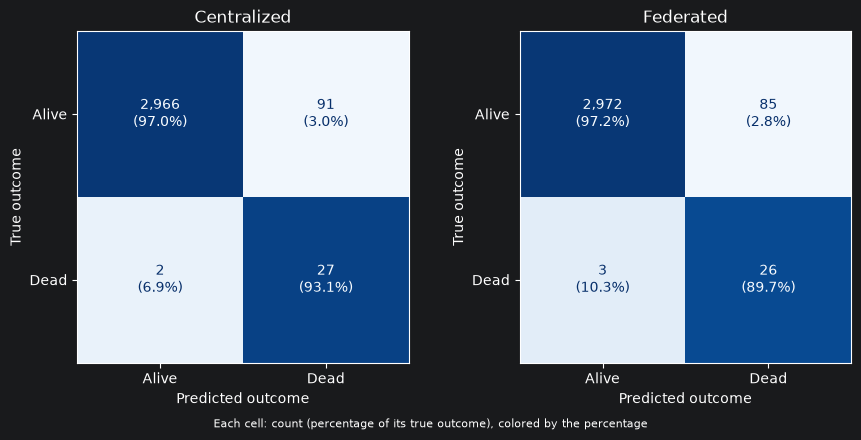

In [27]:
# Centralized: counts on the whole test set. Federated: sum of the counts each institution shared (section 5.5)
counts_centralized = confusion_matrix(y_test, best_model.predict(X_test), labels=[0, 1])
counts_federated = sum(evaluation["counts"] for evaluation in evaluations)

plot_confusion_matrices({"Centralized": counts_centralized, "Federated": counts_federated})

### 6.4. Interpreting the results

- **Both models identify the same main predictors.** `shock`, `organ_damage`, `severe_bleeding`, `postural_hypotension` and `plasma_leakage` have the largest coefficients in both models, and 20 of the 23 coefficients have the same sign. The three that change sign (`hematocrit_increase`, `vomiting`, `myalgia`) are close to zero in both models.
- **The federated coefficients are generally smaller.** Each institution applies the full regularization (section 4.2) to its own data only, which is a small part of the total, so the combined model ends up more regularized than the centralized one, which applies it once to all the data.
- **Despite this, both models predict almost the same.** Which patients get a higher probability of death depends on the relative size of the coefficients, which is very similar in both models, so the AUC barely changes (0.986 and 0.985). The small difference also comes partly from the federated AUC being an average of the institutions' AUCs (section 5.4).
- **The difference in recall is a single death.** The centralized model detects 27 of the 29 deaths and the federated one 26 (0.931 and 0.897). In exchange, the federated model has fewer false alarms (85 and 91), so its precision is slightly higher.
- **Per institution, the metrics are the same or very close.** The largest difference is at H2, where the centralized model detects one more death.

## 7. Conclusions

- **The federated approach reproduces the predictive performance of the centralized approach without sharing any patient records.** Both models reach almost the same metrics and confusion matrices on the same test patients (sections 6.2 and 6.3). The institutions only shared summary values for the scaling, the parameters of their models, and the counts of their evaluations.
- **Both approaches identify the same main predictors, but the federated coefficients are smaller.** Because each institution applies the full regularization to its own data, the federated model is more regularized (section 6.4). Its coefficients are smaller overall, but they keep proportions to each other similar to those of the centralized model, so both models identify the patients at higher risk in the same way.
- **In a prediction model, differences in the coefficients are acceptable as long as the predictions match.** As described in the Introduction, the goal of this notebook is to predict the outcome, not to interpret how each predictor is associated with it, as in `03_odds_ratios.ipynb`. The federated approach therefore doesn't need to reproduce the centralized coefficients, but its predictions, and the metrics and confusion matrices (sections 6.2 and 6.3) show that it does.
- **The number of communication rounds depends on how much each institution trains in each round and on the data of each institution.** In this case, the model needed 217 rounds to converge (section 5.4), because each institution takes a single training step per round (section 5.3). Taking more training steps per round can reduce the number of rounds, and with other data, where the institutions' distributions differ more or less from each other, the number of rounds needed can also change.
- **The differences between the models don't come from their configuration, which was the same in both, but from how that configuration acts on each institution's data.** Both approaches used the same hyperparameters and settings (section 5.3). However, each institution applies the regularization set by `C` to its own data only, which is a small part of the total, so the combined model ends up more regularized than the centralized one (section 6.4). In a real setting, where the centralized data doesn't exist, the value of `C` would also have to be chosen in a federated way.